# Flight Price Sensitivity and Pricing Analysis

# 1-Introduction

Price sensitivity plays a critical role in shaping pricing strategies within the airline industry. Customers respond differently to price changes depending on factors such as booking timing, travel class, and flight characteristics.
In this project, I analyse how these variables influence flight prices, with a particular focus on understanding how sensitive customers are to price fluctuations. By applying regression modelling, I identify the key drivers of price variation and quantify their impact.

The findings provide insights into customer behaviour, highlighting how early booking reduces costs, while premium services significantly increase prices. These insights can support dynamic pricing strategies and help both businesses and consumers make more informed decisions.

In [1]:
# Libraries import 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import statsmodels.api as sm

## 2- Data Overview

In [2]:
# Dataset Info 
df = pd.read_csv('Clean_Dataset.csv')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB
None


## 3- Data Cleaning & Feature Engineering 

In [3]:
# Dropping of Unwanted columns 
df=df.drop(columns=['Unnamed: 0', 'flight'])

In [4]:
df.head(10)

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
5,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.33,1,5955
6,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.08,1,6060
7,Vistara,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.17,1,6060
8,GO_FIRST,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.17,1,5954
9,GO_FIRST,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.25,1,5954


In [5]:
# 1- Price into log_price 
df['log_price']= np.log(df['price'])

In [6]:
# 2- Transformation of categorical data into dummy variables 
df =pd.get_dummies(df, drop_first= True, dtype=int)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 32 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   duration                      300153 non-null  float64
 1   days_left                     300153 non-null  int64  
 2   price                         300153 non-null  int64  
 3   log_price                     300153 non-null  float64
 4   airline_Air_India             300153 non-null  int64  
 5   airline_GO_FIRST              300153 non-null  int64  
 6   airline_Indigo                300153 non-null  int64  
 7   airline_SpiceJet              300153 non-null  int64  
 8   airline_Vistara               300153 non-null  int64  
 9   source_city_Chennai           300153 non-null  int64  
 10  source_city_Delhi             300153 non-null  int64  
 11  source_city_Hyderabad         300153 non-null  int64  
 12  source_city_Kolkata           300153 non-nul

## 4- Correlation Analysis

##  Correlation Analysis Insights

The correlation heatmap reveals that most features exhibit low pairwise correlations, indicating limited multicollinearity within the dataset. This supports the reliability of the regression coefficients and suggests that each variable contributes unique information to the model.

Among the variables, flight duration shows a positive relationship with price, reflecting the impact of distance and operational costs. Airline-related variables also display noticeable correlations, highlighting differences in pricing strategies across carriers, with premium airlines associated with higher fares.

In contrast, variables such as departure time, arrival time, and route-specific indicators demonstrate relatively weak individual correlations with price. This suggests that while these factors may not strongly influence price on their own, their combined effects become more significant within the regression framework.

Overall, the heatmap confirms that pricing is driven by a combination of factors rather than any single dominant variable, aligning with the complexity of real-world airline pricing systems.

<Axes: >

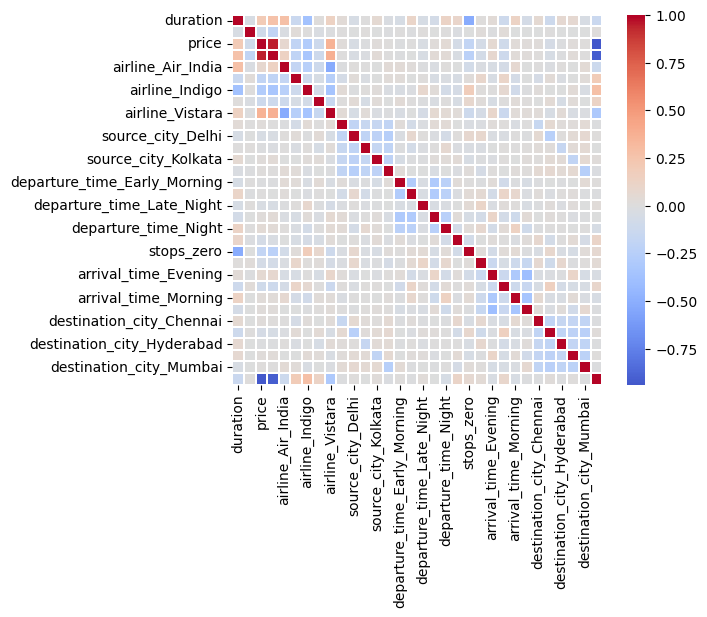

In [8]:
sns.heatmap(df.corr(), cmap="coolwarm", center=0, linewidths=0.3, square=True)

## 6- OLS Model Building

In [9]:
# Target
y = df['log_price']

# Features (drop target + raw price)
X = df.drop(columns=['log_price', 'price'])

In [10]:
X = sm.add_constant(X)

In [11]:
model = sm.OLS(y, X).fit()




## 🔥 Key Insights on Price Sensitivity

⏳ 1. Strong Price Sensitivity to Booking Timing (MOST IMPORTANT)
days_left = -0.0144

👉 Interpretation:

Each additional day before departure → ~1.44% decrease in price
Booking 10 days earlier → ~14% cheaper
💡 Insight:

Customers are highly price-sensitive to booking timing. Early planners benefit significantly from lower prices, while last-minute travellers face steep price increases.

👉 Business implication:

Airlines can increase prices closer to departure due to lower price sensitivity (urgent demand)

💼 2. Low Price Sensitivity for Premium Customers (Business Class)
class_Economy = -2.026

👉 Economy ≈ 87% cheaper than Business

💡 Insight:

Customers choosing business class are significantly less price-sensitive and willing to pay a premium for comfort and flexibility.

👉 Business implication:

Airlines can maintain high margins on premium segments
Price changes have less impact on demand for business travellers

🧳 3. Mixed Price Sensitivity Across Flight Types (Stops)

Reference = 1 stop

stops_zero = -0.452 → ~36% cheaper
stops_two_or_more = +0.224 → ~25% more expensive
💡 Insight:

Price sensitivity varies by journey type. Customers may accept higher prices for more complex routes (multi-stop), while direct flights may be priced more competitively due to higher demand and competition.

👉 Business implication:

Pricing strategy should differ by route complexity
Not all customers respond equally to price changes
✈️ 4. Moderate Sensitivity to Flight Duration
duration = +0.0036

👉 Small but positive effect

💡 Insight:

Customers are relatively less sensitive to duration compared to other factors. Price increases for longer flights are accepted, but the effect is limited.

👉 Business implication:

Duration alone is not a major pricing lever

🏢 5. Airline Choice Reflects Willingness to Pay

Example:

Vistara = +0.646 → ~ 65% higher price
💡 Insight:

Customers show different levels of price sensitivity depending on the airline. Premium airlines attract less price-sensitive customers, while budget airlines cater to more price-sensitive segments.

👉 Business implication:

Strong brand positioning reduces price sensitivity

🌍 6. Geographic Differences in Price Sensitivity

Example:

Kolkata → higher prices
Hyderabad → lower prices
💡 Insight:

Price sensitivity varies by location, likely reflecting differences in demand, competition, and income levels across markets.

👉 Business implication:

Pricing strategies should be location-specific

🕒 7. Time-of-Day Has Limited Impact on Price Sensitivity
Small coefficients (±0.01–0.04)
💡 Insight:

Customers are relatively less sensitive to departure and arrival times compared to other factors like class or booking timing.

👉 Business implication:

Time of day is a secondary pricing lever

🎯 Final Strategic Insight (VERY IMPORTANT)

👉 The model shows two distinct customer behaviours:

🔹 High price-sensitive customers:
Book early
Choose economy
Prefer cheaper airlines
🔹 Low price-sensitive customers:
Book late
Choose business class
Fly premium airlines

🧠 🔥 Strong concluding insight

The analysis reveals that price sensitivity in the airline industry is highly heterogeneous. While early bookers and economy travellers exhibit strong sensitivity to price changes, premium customers and last-minute travellers are significantly less responsive, allowing airlines to implement differentiated pricing strategies to maximise revenue.

In [12]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.915
Model:                            OLS   Adj. R-squared:                  0.915
Method:                 Least Squares   F-statistic:                 1.082e+05
Date:                Fri, 03 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:10:29   Log-Likelihood:                -87421.
No. Observations:              300153   AIC:                         1.749e+05
Df Residuals:                  300122   BIC:                         1.752e+05
Df Model:                          30                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

## 7- Model Diagnostics

## Model Diagnostics Insights

The residual analysis indicates that the model performs well overall. The histogram of residuals shows an approximately normal distribution, suggesting that the model captures the central structure of the data effectively.

However, the Q-Q plot reveals deviations in the tails, indicating the presence of extreme values or outliers. This suggests that while the model explains typical pricing behaviour well, it is less accurate for unusually high or low ticket prices.

These deviations are expected in airline pricing, where factors such as demand surges, seasonal effects, and last-minute bookings can lead to extreme price variations not fully captured by the model.

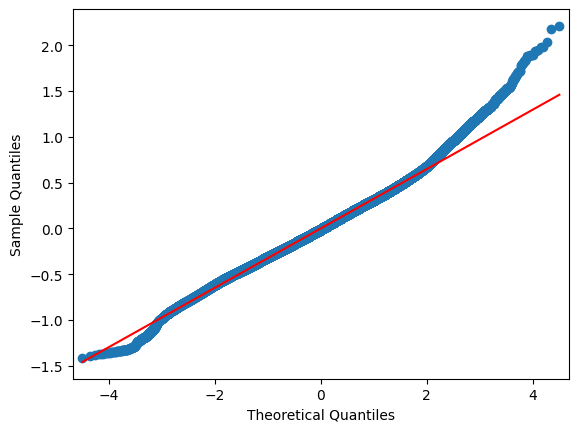

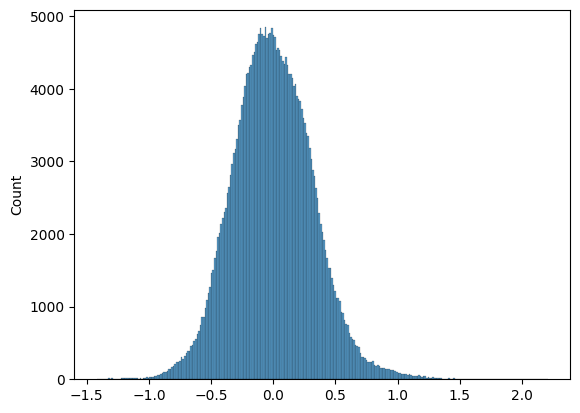

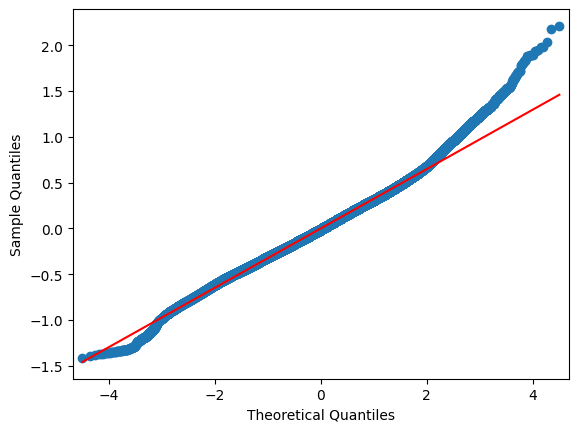

In [13]:
sns.histplot(model.resid)
sm.qqplot(model.resid, line='s')